
# 02425 Diffusion and stochastich differential equations


## WEEK 3: Brownian motion

In [99]:
import numpy as np
import random
from numpy import random
from matplotlib import pyplot as plt
import scipy.stats as stats


In this exercises we will look at the Brownian motion phenomena. Here we will study some of its charachteristics.

### Exercise 1

In [100]:
def Brownian(partition):

    BrownianMotion = np.array([])

    for i in range(len(partition)):

        if partition[i] == 0:
            BrownianMotion = np.append(BrownianMotion, 0)
        if partition[i] != 0:
            BrownianMotion = np.append(BrownianMotion, random.normal(loc=BrownianMotion[-1], scale=np.sqrt(partition[i]-partition[i-1])))

    return BrownianMotion

### Exercise 2

#### 1

In [101]:
T = 1
dt = 0.001
N = 10000

partition = np.linspace(0, T, int(T/dt))

observations = np.empty((0, int(T/dt)))

for i in range(N):

    observations = np.vstack([observations, Brownian(partition)])


#### 2

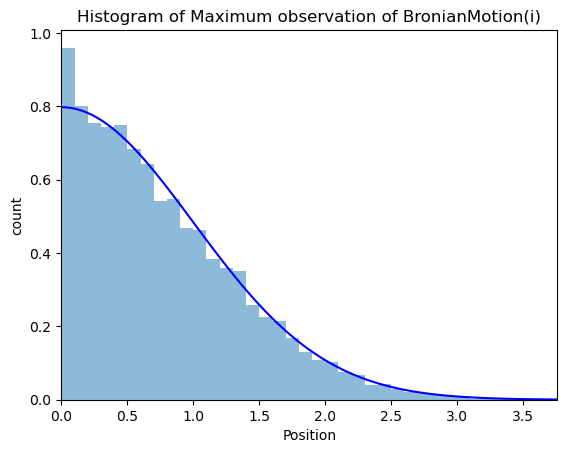

In [102]:
maxList = np.array([])

for i in range(N):
    maxList = np.append(maxList, max(observations[i]))

maxList

bins = np.arange(-10, 10, 0.01) # fixed bin size
bins = np.arange(0, 4, 0.1)

x_funktion = np.linspace(0, max(maxList),100)
y_funktion = (2/np.sqrt(T)) * stats.norm.pdf(x_funktion/np.sqrt(T))


plt.xlim([min(maxList), max(maxList)])

plt.plot(x_funktion, y_funktion, color='blue', label='C(x,t)')

plt.hist(maxList, bins=bins, density=True, alpha=0.5)
plt.title('Histogram of Maximum observation of BronianMotion(i)')
plt.xlabel('Position')
plt.ylabel('count')

plt.show()

#### 3

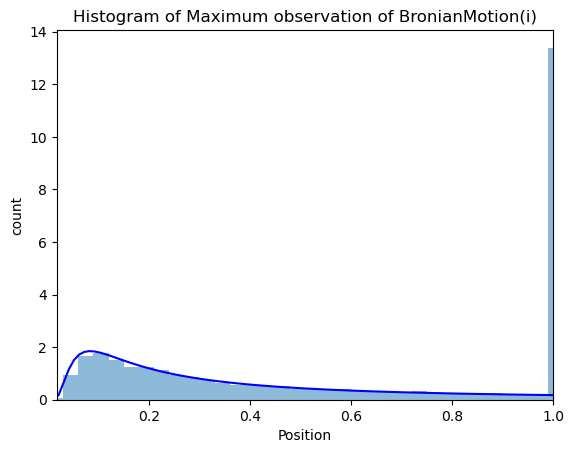

In [103]:
HT = np.array([])

b = 0.5

for i in range(len(observations)):

    minn = 1

    for j in range(len(observations[0])):

        if observations[i][j] >= b:
            minn = partition[j]
            break


    HT = np.append(HT, minn)

bins = np.arange(0, 1.05, 0.03)


x_funktion = np.linspace(0.001, 1, 100)

y_funktion = b * x_funktion**(-3/2) * stats.norm.pdf(b/np.sqrt(x_funktion))

plt.xlim([min(HT), max(HT)])

plt.plot(x_funktion, y_funktion, color='blue', label='C(x,t)')

plt.hist(HT, bins=bins, density=True, alpha=0.5)
plt.title('Histogram of Maximum observation of BronianMotion(i)')
plt.xlabel('Position')
plt.ylabel('count')

plt.show()

### Exercise 3

#### 1

In [104]:
T = 1
dt = 2**(-20)
N = 1

partition = np.linspace(0, T, int(T/dt))

observations = np.empty((0, int(T/dt)))

for i in range(N):

    observations = np.vstack([observations, Brownian(partition)])


We can plot the brownian motion.

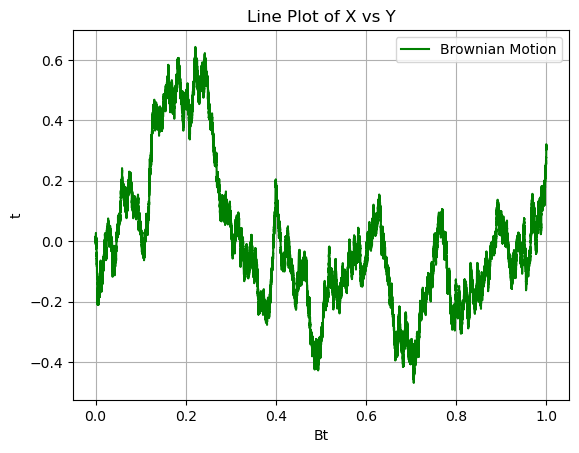

In [105]:

plt.plot(partition, observations[0], linestyle='-', color='g', label='Brownian Motion')


plt.title('Line Plot of X vs Y')
plt.xlabel('Bt')
plt.ylabel('t')


plt.grid(True)
plt.legend()

# Display the final plot
plt.show()

#### 2

In [106]:
def DiscretizedTotalVar(observation):
    val = 0
    for i in range(len(observation)-1):
        val += np.abs(observation[i+1] - observation[i])

    return val

def DiscretizedQuadraticVar(observation):
    val = 0
    for i in range(len(observation)-1):
        val += np.abs(observation[i+1] - observation[i])**2

    return val



print("Discretized Total Variation:", DiscretizedTotalVar(observations[0]))
print("Discretized Quadratic Variation:", DiscretizedQuadraticVar(observations[0]))

Discretized Total Variation: 817.7141377839667
Discretized Quadratic Variation: 1.0009644414225558


#### 3

We will now subsample our observations.

In [107]:
print("Discretized Total Variation:", DiscretizedTotalVar(observations[0][::2]))
print("Discretized Quadratic Variation:", DiscretizedQuadraticVar(observations[0][::2]))

Discretized Total Variation: 578.089341816798
Discretized Quadratic Variation: 1.000447642314061


#### 4

We can now do this for all until we get time step $2^{-10}$, And save the observations.

In [108]:
DTV = np.array([DiscretizedTotalVar(observations[0])])
DQV = np.array([DiscretizedQuadraticVar(observations[0])])

list = np.array(observations[0])

timestep = np.array([2**(-20)])


for i in range(1, 11):
    DTV = np.append(DTV, DiscretizedTotalVar(list[::2]))
    DQV = np.append(DQV, DiscretizedQuadraticVar(list[::2]))  
    timestep = np.append(timestep, timestep[-1]*2)
    list = np.array(list[::2])

In [109]:
timestep

array([9.53674316e-07, 1.90734863e-06, 3.81469727e-06, 7.62939453e-06,
       1.52587891e-05, 3.05175781e-05, 6.10351562e-05, 1.22070312e-04,
       2.44140625e-04, 4.88281250e-04, 9.76562500e-04])

#### 5

Now we can plot Discretized total variance, and the Disrcretized quadratic variance as a function of the timestep.

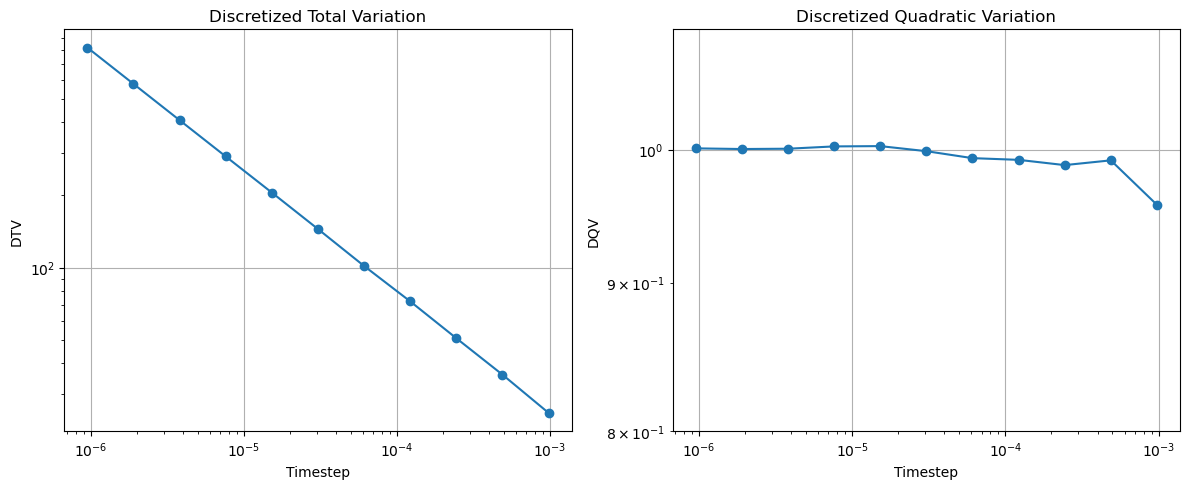

In [110]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))


ax[0].loglog(timestep, DTV, marker='o')
ax[0].set_title('Discretized Total Variation')
ax[0].set_xlabel('Timestep')
ax[0].set_ylabel('DTV')
ax[0].grid(True)


ax[1].loglog(timestep, DQV, marker='o')
ax[1].set_title('Discretized Quadratic Variation')
ax[1].set_xlabel('Timestep')
ax[1].set_ylabel('DQV')
ax[1].grid(True)
ax[1].set_ylim(0.8, 1.1)

plt.tight_layout()
plt.show()

## Basic Martingales

### Exercise 4

$$E [B_{t}^{2}-t]=-t +E [B_{t}^{2}]=-t +\int_{-\infty}^{\infty}\frac{1}{\sqrt{t}\cdot \sqrt{2\cdot \pi}}\cdot \exp (-\frac{x^{2}}{2\cdot \sqrt{\mathrm{t}}^{2}})\cdot x^{2}d x =-t +t =0$$

### Exercise 5

We assume that $E[X]< \infty $ And we want to show that the process gives as $\mathrm{M}_{t}=E [X | F_{t}]$ is a martingale. here we let ${\{F_{t}\colon t \ge 0\}}$ be a filtration on the process $M_t$.

First we want to show that $M_t$ is $F_t$ measurable. But its clear that since the definition of $M_t$ is the conditional expextation of $X$ given $F_t$, then it has to be $F_t$ measurable.

Now we want to show that its bounded. This can be shown by the following calculation.

$$E [{\vert M_{t}\vert}]=E \left[| E \left[X | F_{t}\right]| \right]\le E [E [{\vert X | \vert}F_{t}]]=E \left[|X| \right]<\infty $$

Note that the last equality comes from the tower property.

Now we want to show that $E[M_t|F_s]=M_s$. This can be shown by the following calculations.

$$E[M_t \mid F_s] = E[E[X \mid F_t] \mid F_s] = E[X \mid F_s] = M_s$$


Now we have shown that the defined process indeed is a martingale.

### Exercise 6

Assume that $0 \le s \le t \le u \le v$. Notice that $M_t$ is a martingale per definition, which means that the increments have a expectation of zero. We want to show that $\mathit{Cov} (M_{v}-M_{u},M_{t}-M_{s})=0$. Notice that since the increments has expectation zero we have the following:

$$\mathit{Cov} (M_{v}-M_{u},M_{t}-M_{s})=E [(M_{v}-M_{u})(M_{t}-M_{s})]$$

We can now use the tower property by conditioning on $F_u$. We then have that the following holds.

$$E [(M_{v}-M_{u})(M_{t}-M_{s})]=E \left[E [(M_{v}-M_{u})(M_{t}-M_{s})]| F_{u}\right]$$

Since we are using the filtration on the time $u$, we have observeded everything in the past. Therefore we can pull out the coefficient regarding the previous values of the process.

$$E \left[E [(M_{v}-M_{u})(M_{t}-M_{s})]| F_{u}\right]=E [(M_{t}-M_{s})E [(M_{v}-M_{u})| F_{u}]]$$

Notice that $E [(M_{v}-M_{u})]=0$. Therefore we conclude the following:

$$\mathit{Cov} (M_{v}-M_{u},M_{t}-M_{u})=E [(M_{v}-M_{u})(M_{t}-M_{u})]=E \left[E [(M_{v}-M_{u})(M_{t}-M_{u})]| F_{u}\right]=E [(M_{t}-M_{s})E [(M_{v}-M_{u})| F_{u}]]=E [(M_{t}-M_{s})\cdot 0]=0$$

Now we are interested in showing that the variance is additive. With other words that the variance of the process from time lets say $s$ to $u$ is the same of the variance of the process from $s$ to $t$ additioned with the variance of the process from $t$ to $u$. Now consider that $V (X +Y)=V (X)+V (Y)+2\mathit{Cov} (X ,Y)$. What we are interesting to show is $V (M_{u}-M_{s})=V (M_{u}-M_{t})+V (M_{t}-M_{s})$. Now see that we can rewrite is as $V (M_{u}-M_{s})=V ((M_{u}-M_{t})+(M_{t}-M_{s}))$. Now you can consider the right hanc side as the variance as random variables, and apply the rule given in the start. 

$$V (M_{u}-M_{s})=V ((M_{u}-M_{t})+(M_{t}-M_{s}))=V (M_{u}-M_{t})+V (M_{t}-M_{s})+2\mathit{cov} ((M_{u}-M_{t}),(M_{t}-M_{s}))$$

Notice that we previously found that $\mathit{cov}\left(\left(M_{u}-M_{t}\right),\left(M_{t}-M_{s}\right)\right)=0$

Therfore we have that

$$V\left(M_{u}-M_{s}\right)=V\left(\left(M_{u}-M_{t}\right)+\left(M_{t}-M_{s}\right)\right)=V\left(M_{u}-M_{t}\right)+V\left(M_{t}-M_{s}\right)$$



Now we wants to show that the variance of the process is incresing, with other words $V (M_{s})\le V (M_{t})$, assuming $s \le t$. Now see that $M_t = M_t + M_s - M_s$. From the previouse calculations we can show that $V (M_{t})=V (M_{s})+V (M_{t}-M_{s})$. Now out interest is only showing that $V (M_{t})\ge V (M_{s})$. Since the variance is always nonnegative, we have that $V (M_{t}-M_{s})\ge 0$. Therfore we have that $V\left(M_{t}\right)\ge V\left(M_{s}\right)$. Notice that if we are working with browinian motion. then the covariance of the increments is always greater that zero. Which means that the variance of the process is actually not only an increasing process, but a strictly increasing process.